# 05 — PyCaret Benchmark

Objetivo:

> Comparar varios regresores de PyCaret usando exactamente las **16 features del experimento S2**, sin cambiar el target ni volver a hacer ingeniería de variables.

## Regla metodológica

PyCaret se utiliza para **descubrir modelos candidatos**, pero la clasificación final se recalcula con `TimeSeriesSplit` de scikit-learn sobre todo el período pre-2018 ordenado cronológicamente.

Esto evita depender del split interno de PyCaret para decidir el ganador.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

import pycaret
from pycaret.regression import RegressionExperiment

print("PyCaret version:", pycaret.__version__)

PROJECT_ROOT = Path.cwd().parent
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

DATA_FILE = DATA_PROCESSED / "seasonal_model_s2.csv"

TARGET_COLUMN = "target_anomaly_next3m"

TRAIN_VAL_END = pd.Timestamp("2017-12-01")
TEST_START = pd.Timestamp("2018-01-01")

print("Proyecto:", PROJECT_ROOT)

PyCaret version: 4.0.0a8
Proyecto: /home/gustavo-paredes/Documents/Developer/Yachay/enso-ml


## 1. Features definitivas de S2

In [2]:
enso_variables = [
    "nino12",
    "nino3",
    "nino34",
    "nino4",
    "soi",
    "tni",
]

enso_features = []
for variable in enso_variables:
    enso_features.extend([
        variable,
        f"{variable}_ma3",
    ])

seasonal_features = [
    "target_month_sin",
    "target_month_cos",
]

precip_features = [
    "precip_anomaly",
    "precip_anomaly_ma3",
]

FEATURES = (
    enso_features
    + seasonal_features
    + precip_features
)

print("Número de features:", len(FEATURES))
print(FEATURES)

assert len(FEATURES) == 16

Número de features: 16
['nino12', 'nino12_ma3', 'nino3', 'nino3_ma3', 'nino34', 'nino34_ma3', 'nino4', 'nino4_ma3', 'soi', 'soi_ma3', 'tni', 'tni_ma3', 'target_month_sin', 'target_month_cos', 'precip_anomaly', 'precip_anomaly_ma3']


## 2. Cargar dataset y separar pre-2018 / test

In [3]:
df = pd.read_csv(
    DATA_FILE,
    parse_dates=[
        "date",
        "target_start",
        "target_center",
        "target_end",
    ],
)

df = (
    df.sort_values("date")
      .reset_index(drop=True)
)

required_columns = (
    FEATURES
    + [
        TARGET_COLUMN,
        "date",
        "target_start",
        "target_end",
        "precip_anomaly_ma3",
    ]
)

missing = [
    c for c in required_columns
    if c not in df.columns
]

assert not missing, f"Faltan columnas: {missing}"

pre2018 = df[
    df["target_end"] <= TRAIN_VAL_END
].copy()

final_test = df[
    df["target_start"] >= TEST_START
].copy()

print("Pre-2018:", pre2018.shape)
print(
    "Target pre-2018:",
    pre2018["target_start"].min(),
    "->",
    pre2018["target_end"].max(),
)

print("\nTest:", final_test.shape)
print(
    "Target test:",
    final_test["target_start"].min(),
    "->",
    final_test["target_end"].max(),
)

Pre-2018: (799, 21)
Target pre-2018: 1950-04-01 00:00:00 -> 2017-12-01 00:00:00

Test: (91, 21)
Target test: 2018-01-01 00:00:00 -> 2025-12-01 00:00:00


In [4]:
X_pre = pre2018[FEATURES].copy()
y_pre = pre2018[TARGET_COLUMN].copy()

X_test = final_test[FEATURES].copy()
y_test = final_test[TARGET_COLUMN].copy()

assert not X_pre.isna().any().any()
assert not y_pre.isna().any()
assert not X_test.isna().any().any()
assert not y_test.isna().any()

print("X pre-2018:", X_pre.shape)
print("X test:", X_test.shape)

X pre-2018: (799, 16)
X test: (91, 16)


## 3. Crear experimento PyCaret

PyCaret recibe únicamente las 16 features y el target.

La clasificación producida directamente por `compare_models()` se considera **exploratoria**. La selección que utilizaremos después se recalculará con nuestro propio `TimeSeriesSplit`.


In [5]:
pycaret_data = pre2018[
    FEATURES + [TARGET_COLUMN]
].copy()

exp = RegressionExperiment(
    target=TARGET_COLUMN,
    session_id=42,
    train_size=0.90,
    normalize=True,
).fit(pycaret_data)

print("PyCaret experiment ready.")

PyCaret experiment ready.


## 4. Descubrir modelos candidatos con PyCaret

Pedimos hasta 20 candidatos. Si algún modelo opcional no está instalado, PyCaret simplemente trabajará con los modelos disponibles en su registro.

La tabla de esta celda **no será nuestra clasificación definitiva**.


In [6]:
comparison = exp.compare_models(
    sort="RMSE",
    n_select=20,
    turbo=True,
    errors="ignore",
)

pycaret_leaderboard = comparison.leaderboard.copy()

pycaret_leaderboard

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,et,31.5234,1884.5781,43.2811,0.5919,1.2379,3.2841
1,gbr,32.8386,1930.8845,43.7477,0.5899,1.3000,2.9043
2,rf,32.9232,2005.3270,44.6315,0.5697,1.2258,3.4749
3,lr,34.7395,2075.4980,45.3748,0.5624,1.2290,4.5612
4,ridge,34.6574,2088.7725,45.5005,0.5610,1.2456,4.7021
5,huber,34.1167,2091.7669,45.5019,0.5631,1.2203,4.0739
6,kr,34.5973,2091.7174,45.5366,0.5607,1.2340,4.8743
7,br,34.7219,2101.4354,45.6348,0.5586,1.2521,4.6918
8,tr,34.3112,2133.2933,45.9282,0.5560,1.2417,4.1055
9,ard,35.2113,2149.0164,46.1525,0.5487,1.2522,4.7889


In [7]:
candidate_models = comparison.models
candidate_ids = comparison.ranked_ids

print("Candidatos devueltos:", len(candidate_models))
print(candidate_ids)

assert len(candidate_models) == len(candidate_ids)

Candidatos devueltos: 20
['et', 'gbr', 'rf', 'lr', 'ridge', 'huber', 'kr', 'br', 'tr', 'ard', 'knn', 'lasso', 'llar', 'par', 'ada', 'en', 'omp', 'ransac', 'dt', 'svm', 'dummy', 'lar']


AssertionError: 

## 5. Re-evaluación estricta con TimeSeriesSplit

Esta es la comparación que utilizaremos para elegir el mejor candidato.

Cada pipeline de PyCaret se clona y se vuelve a entrenar desde cero dentro de cada fold temporal:

- entrenamiento siempre contiene observaciones anteriores;
- validación siempre contiene observaciones posteriores;
- no usamos 2018–2025 para seleccionar el modelo.


In [8]:
tscv = TimeSeriesSplit(
    n_splits=5
)

scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2",
}

cv_rows = []

for model_id, pipeline in zip(
    candidate_ids,
    candidate_models,
):
    print("Evaluando:", model_id)

    try:
        scores = cross_validate(
            clone(pipeline),
            X_pre,
            y_pre,
            cv=tscv,
            scoring=scoring,
            n_jobs=-1,
            error_score="raise",
        )

        cv_rows.append({
            "model_id": model_id,
            "MAE_mean": -scores["test_MAE"].mean(),
            "MAE_std": scores["test_MAE"].std(),
            "RMSE_mean": -scores["test_RMSE"].mean(),
            "RMSE_std": scores["test_RMSE"].std(),
            "R2_mean": scores["test_R2"].mean(),
            "R2_std": scores["test_R2"].std(),
        })

    except Exception as exc:
        print(
            f"  -> omitido por error: "
            f"{type(exc).__name__}: {exc}"
        )

strict_cv_results = (
    pd.DataFrame(cv_rows)
    .sort_values(
        ["RMSE_mean", "MAE_mean"]
    )
    .reset_index(drop=True)
)

strict_cv_results

Evaluando: et
Evaluando: gbr
Evaluando: rf
Evaluando: lr
Evaluando: ridge
Evaluando: huber
Evaluando: kr


/home/gustavo-paredes/Documents/Developer/Yachay/enso-ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_huber.py:348: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/home/gustavo-paredes/Documents/Developer/Yachay/enso-ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_huber.py:348: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result

Evaluando: br
Evaluando: tr
Evaluando: ard
Evaluando: knn
Evaluando: lasso
Evaluando: llar
Evaluando: par
Evaluando: ada


/home/gustavo-paredes/Documents/Developer/Yachay/enso-ml/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:71: FutureWarning: Class PassiveAggressiveRegressor is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDRegressor(loss='epsilon_insensitive', penalty=None, learning_rate='pa1', eta0 = 1.0)` instead.
  warnings.warn(msg, category=FutureWarning)
/home/gustavo-paredes/Documents/Developer/Yachay/enso-ml/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:71: FutureWarning: Class PassiveAggressiveRegressor is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDRegressor(loss='epsilon_insensitive', penalty=None, learning_rate='pa1', eta0 = 1.0)` instead.
  warnings.warn(msg, category=FutureWarning)
/home/gustavo-paredes/Documents/Developer/Yachay/enso-ml/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:71: FutureWarning: Class PassiveAggressiveRegressor is deprecated; this is deprec

Evaluando: en
Evaluando: omp
Evaluando: ransac
Evaluando: dt
Evaluando: svm


,model_id,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
0,kr,37.662872,5.796279,49.601898,6.497923,0.349090,0.264426
1,br,37.048163,4.055018,50.006455,5.881554,0.349644,0.244697
2,tr,36.946135,6.264974,50.433792,8.109433,0.342758,0.252284
3,ard,37.399926,4.369923,50.443341,6.288489,0.336087,0.253799
4,ridge,37.553509,5.383345,50.455626,7.303698,0.332847,0.265127
5,lr,37.976558,6.572818,50.715675,8.564768,0.324029,0.281056
6,lasso,37.553806,3.698481,51.022166,5.435201,0.320198,0.260687
7,llar,37.553835,3.698912,51.022337,5.435573,0.320202,0.260667
8,huber,38.053718,6.924521,51.571163,8.852060,0.310609,0.273651
9,en,37.620916,3.920492,51.665487,5.910224,0.320531,0.231906


## 6. Referencias conocidas con el mismo TimeSeriesSplit

Para que la comparación sea justa, volvemos a medir:

- regresión lineal S2;
- Ridge;
- baseline climatológico;
- persistencia de 3 meses.

Los baselines no necesitan entrenamiento, por lo que se calculan directamente dentro de cada fold de validación.


In [9]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge

manual_models = {
    "S2 Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression()),
    ]),
    "S2 Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0)),
    ]),
}

manual_rows = []

for model_name, model in manual_models.items():
    scores = cross_validate(
        model,
        X_pre,
        y_pre,
        cv=tscv,
        scoring=scoring,
        n_jobs=-1,
    )

    manual_rows.append({
        "model": model_name,
        "MAE_mean": -scores["test_MAE"].mean(),
        "RMSE_mean": -scores["test_RMSE"].mean(),
        "R2_mean": scores["test_R2"].mean(),
    })

manual_cv_results = pd.DataFrame(manual_rows)

manual_cv_results

,model,MAE_mean,RMSE_mean,R2_mean
0,S2 Linear Regression,37.976558,50.715675,0.324029
1,S2 Ridge,37.553509,50.455626,0.332847


In [10]:
def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "R2": r2_score(y_true, y_pred),
    }

baseline_fold_rows = []

for fold_number, (_, val_idx) in enumerate(
    tscv.split(X_pre),
    start=1,
):
    y_fold = y_pre.iloc[val_idx]

    climatology_pred = np.zeros(
        len(val_idx)
    )

    persistence_pred = (
        pre2018
        .iloc[val_idx]["precip_anomaly_ma3"]
        .to_numpy()
    )

    baseline_fold_rows.append({
        "fold": fold_number,
        "baseline": "Climatology",
        **regression_metrics(
            y_fold,
            climatology_pred,
        ),
    })

    baseline_fold_rows.append({
        "fold": fold_number,
        "baseline": "3M Persistence",
        **regression_metrics(
            y_fold,
            persistence_pred,
        ),
    })

baseline_cv_results = (
    pd.DataFrame(baseline_fold_rows)
    .groupby("baseline", as_index=False)
    .agg(
        MAE_mean=("MAE", "mean"),
        RMSE_mean=("RMSE", "mean"),
        R2_mean=("R2", "mean"),
    )
    .sort_values("RMSE_mean")
)

baseline_cv_results

,baseline,MAE_mean,RMSE_mean,R2_mean
0,3M Persistence,44.817376,59.317062,0.038241
1,Climatology,46.440636,68.234351,-0.036173


## 7. Seleccionar el candidato PyCaret por CV temporal

La selección se hace únicamente con `RMSE_mean` pre-2018.


In [11]:
best_model_id = strict_cv_results.iloc[0]["model_id"]

best_position = candidate_ids.index(
    best_model_id
)

best_pycaret_pipeline = clone(
    candidate_models[best_position]
)

print("Mejor candidato PyCaret:", best_model_id)
print(
    strict_cv_results.iloc[0][
        [
            "MAE_mean",
            "RMSE_mean",
            "R2_mean",
        ]
    ]
)

Mejor candidato PyCaret: kr
MAE_mean     37.662872
RMSE_mean    49.601898
R2_mean        0.34909
Name: 0, dtype: object


## 8. Comparación resumida pre-2018

Esta tabla combina el mejor candidato AutoML con nuestros modelos manuales y baselines.


In [12]:
summary_rows = []

best_cv = strict_cv_results.iloc[0]

summary_rows.append({
    "model": f"PyCaret — {best_model_id}",
    "MAE": best_cv["MAE_mean"],
    "RMSE": best_cv["RMSE_mean"],
    "R2": best_cv["R2_mean"],
})

for _, row in manual_cv_results.iterrows():
    summary_rows.append({
        "model": row["model"],
        "MAE": row["MAE_mean"],
        "RMSE": row["RMSE_mean"],
        "R2": row["R2_mean"],
    })

for _, row in baseline_cv_results.iterrows():
    summary_rows.append({
        "model": row["baseline"],
        "MAE": row["MAE_mean"],
        "RMSE": row["RMSE_mean"],
        "R2": row["R2_mean"],
    })

pre2018_comparison = (
    pd.DataFrame(summary_rows)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

pre2018_comparison

,model,MAE,RMSE,R2
0,PyCaret — kr,37.662872,49.601898,0.349090
1,S2 Ridge,37.553509,50.455626,0.332847
2,S2 Linear Regression,37.976558,50.715675,0.324029
3,3M Persistence,44.817376,59.317062,0.038241
4,Climatology,46.440636,68.234351,-0.036173


## 9. Benchmark post-hoc sobre 2018–2025

Solo llegamos a esta celda **después** de seleccionar el candidato mediante CV temporal pre-2018.

Recordatorio: este período ya fue observado anteriormente en el proyecto, así que esta comparación sirve para decidir ingeniería/implementación, pero no debe presentarse como un nuevo test completamente ciego.


In [13]:
# Entrenar candidato PyCaret con TODO pre-2018.
best_pycaret_pipeline.fit(
    X_pre,
    y_pre,
)

pycaret_test_pred = (
    best_pycaret_pipeline.predict(
        X_test
    )
)

# Nuestro modelo S2 original.
linear_final = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression()),
])

linear_final.fit(
    X_pre,
    y_pre,
)

linear_test_pred = linear_final.predict(
    X_test
)

# Baselines
climatology_test_pred = np.zeros(
    len(y_test)
)

persistence_test_pred = (
    final_test["precip_anomaly_ma3"]
    .to_numpy()
)

test_comparison = pd.DataFrame([
    {
        "model": f"PyCaret — {best_model_id}",
        **regression_metrics(
            y_test,
            pycaret_test_pred,
        ),
    },
    {
        "model": "S2 Linear Regression",
        **regression_metrics(
            y_test,
            linear_test_pred,
        ),
    },
    {
        "model": "3M Persistence",
        **regression_metrics(
            y_test,
            persistence_test_pred,
        ),
    },
    {
        "model": "Climatology",
        **regression_metrics(
            y_test,
            climatology_test_pred,
        ),
    },
])

test_comparison = (
    test_comparison
    .sort_values("RMSE")
    .reset_index(drop=True)
)

test_comparison

,model,MAE,RMSE,R2
0,3M Persistence,38.242818,49.305356,0.255177
1,PyCaret — kr,39.654862,51.550176,0.185811
2,S2 Linear Regression,40.069239,52.246207,0.163676
3,Climatology,49.737596,64.912517,-0.290987


## 10. Gráfico comparativo del período 2018–2025

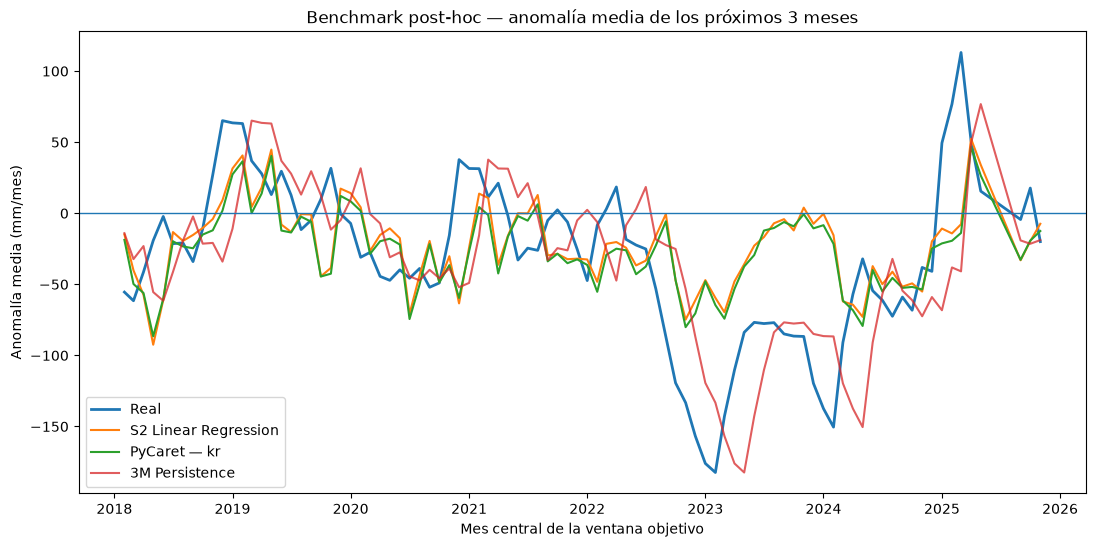

In [14]:
fig, ax = plt.subplots(
    figsize=(13, 6)
)

ax.plot(
    final_test["target_center"],
    y_test.to_numpy(),
    label="Real",
    linewidth=2,
)

ax.plot(
    final_test["target_center"],
    linear_test_pred,
    label="S2 Linear Regression",
)

ax.plot(
    final_test["target_center"],
    pycaret_test_pred,
    label=f"PyCaret — {best_model_id}",
)

ax.plot(
    final_test["target_center"],
    persistence_test_pred,
    label="3M Persistence",
    alpha=0.75,
)

ax.axhline(
    0,
    linewidth=1,
)

ax.set_title(
    "Benchmark post-hoc — anomalía media de los próximos 3 meses"
)
ax.set_xlabel(
    "Mes central de la ventana objetivo"
)
ax.set_ylabel(
    "Anomalía media (mm/mes)"
)
ax.legend()

plt.show()

## 11. Guardar resultados del benchmark

In [15]:
strict_cv_results.to_csv(
    DATA_PROCESSED / "pycaret_strict_temporal_cv.csv",
    index=False,
)

pre2018_comparison.to_csv(
    DATA_PROCESSED / "pycaret_pre2018_comparison.csv",
    index=False,
)

test_comparison.to_csv(
    DATA_PROCESSED / "pycaret_posthoc_test_comparison.csv",
    index=False,
)

print("Resultados guardados.")

Resultados guardados.


In [16]:
best_pycaret_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('kr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](16,)","['nino12','nino12_ma3','nino3',...,'target_month_cos','precip_anomaly', 'precip_anomaly_ma3']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,16
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical_pipeline', ...)]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix 

In [17]:
best_pycaret_pipeline.get_params()

{'memory': None,
 'steps': [('preprocess',
   ColumnTransformer(transformers=[('numerical_pipeline',
                                    Pipeline(steps=[('imputer', SimpleImputer()),
                                                    ('scaler', StandardScaler())]),
                                    ['nino12', 'nino12_ma3', 'nino3', 'nino3_ma3',
                                     'nino34', 'nino34_ma3', 'nino4', 'nino4_ma3',
                                     'soi', 'soi_ma3', 'tni', 'tni_ma3',
                                     'target_month_sin', 'target_month_cos',
                                     'precip_anomaly', 'precip_anomaly_ma3'])],
                     verbose_feature_names_out=False)),
  ('kr', KernelRidge())],
 'transform_input': None,
 'verbose': False,
 'preprocess': ColumnTransformer(transformers=[('numerical_pipeline',
                                  Pipeline(steps=[('imputer', SimpleImputer()),
                                                  ('scaler',